# AI/ML Bootcamp Lecture 5

## MNIST Handwritten digit classifier continued
For this in-class exercise we will look at the MNIST handwritten digit dataset and do some denoising!

### Imports and style

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
height = 5
plt.rcParams["figure.figsize"] = [1.618*height, height]

### Load the MNIST data into a NumPy arrays

In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

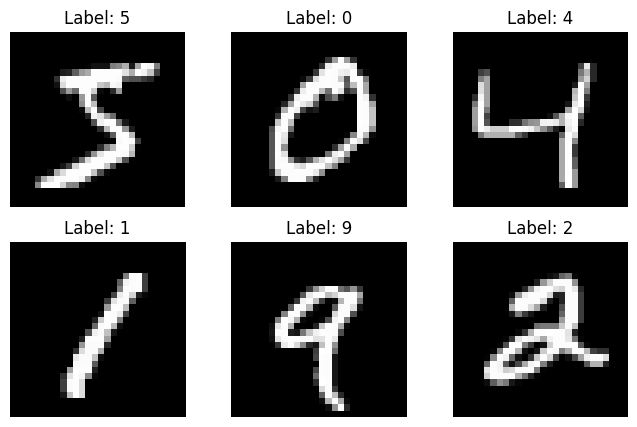

In [ ]:
# Plot 6 images from the training set
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

In [ ]:
# Let's add some noise
clean_images = train_images.astype("float32") / 255.0
clean_images = clean_images[..., None]
clean_test_images = test_images.astype("float32") / 255.0
clean_test_images = clean_test_images[..., None]

noise_sigma = 0.3
noisy_images = clean_images + noise_sigma * np.random.normal(size=clean_images.shape)
noisy_images = np.clip(noisy_images, 0, 1)
noisy_test_images = clean_test_images + noise_sigma * np.random.normal(size=clean_test_images.shape)
noisy_test_images = noisy_test_images[..., None]

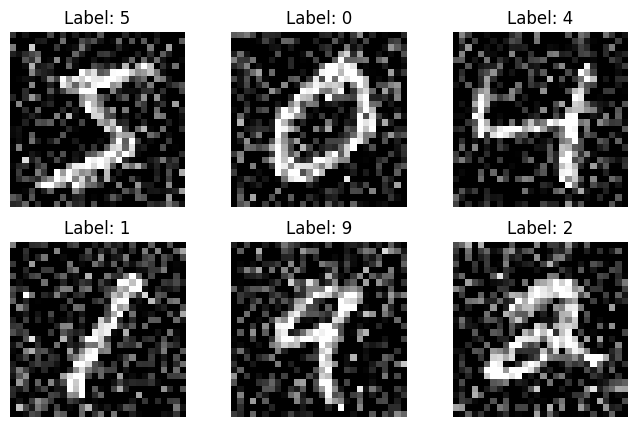

In [ ]:
# Plot 6 images from the noisy training set
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(noisy_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

### Regression Example
Calculate the total ink used from the MNIST data then use regression to predict the total ink used with a neural network

In [ ]:
# Regression example. Let's take the MNIST data and create a regression for the total ink used
total_ink = np.sum(train_images, axis=(1, 2))
total_ink_test = np.sum(test_images, axis=(1, 2))


In [ ]:
total_ink

array([27525, 31095, 19443, ..., 22132, 20428, 20920], dtype=uint64)

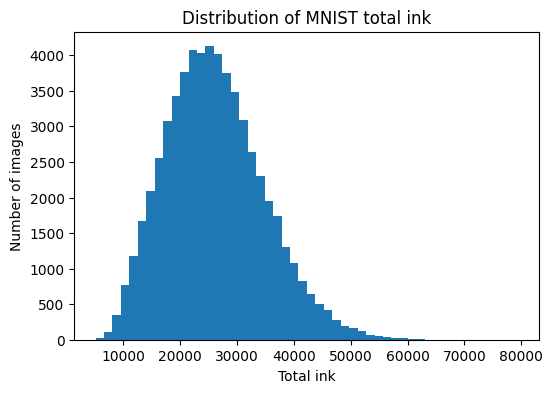

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(total_ink, bins=50)
plt.xlabel("Total ink")
plt.ylabel("Number of images")
plt.title("Distribution of MNIST total ink")
plt.show()